# 07 Dashboard Export Assets

Purpose: prepare compact, reviewer-readable tables and preview visuals that the Streamlit dashboard can load quickly.

This notebook is the bridge between modeling notebooks and the executive dashboard. It answers:

- What files does the dashboard need?
- Which model outputs are used in the dashboard?
- Which tables are compact enough for BI rendering?
- What validation checks prove the dashboard assets are ready?
- What should a reviewer understand before trusting the dashboard?


## Why This Notebook Exists

The earlier notebooks create detailed modeling and EDA outputs. A dashboard should not load every raw row or every intermediate table. It should load small, stable data contracts.

This notebook creates and validates those contracts:

- Forecast summary tables
- Best-model summary
- Growth opportunity table
- PA risk summary
- Delay risk summary
- Validation summary
- Dashboard data contract inventory


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 140)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / "data" / "processed"
TABLE_DIR = ROOT / "reports" / "tables"
FIGURE_DIR = ROOT / "reports" / "figures"
DOC_ASSET_DIR = ROOT / "docs" / "assets" / "dashboard_07"

for folder in [TABLE_DIR, FIGURE_DIR, DOC_ASSET_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Report tables: {TABLE_DIR}")


Project root: D:\Project 1\rcm-cms-mvp
Processed data: D:\Project 1\rcm-cms-mvp\data\processed
Report tables: D:\Project 1\rcm-cms-mvp\reports\tables


## Required Dashboard Inputs

Reason: before exporting dashboard assets, confirm the pipeline has produced every required file. Missing dashboard inputs should fail early here instead of failing inside Streamlit.


In [2]:
required_inputs = [
    ("monthly national enrollment", PROCESSED_DIR / "ma_scp_monthly_national.parquet"),
    ("forecast results", PROCESSED_DIR / "forecast_results.csv"),
    ("forecast metrics", TABLE_DIR / "forecast_metrics.csv"),
    ("state growth", TABLE_DIR / "ma_scp_state_growth.csv"),
    ("state monthly", PROCESSED_DIR / "ma_scp_state_monthly.parquet"),
    ("plan monthly", PROCESSED_DIR / "ma_scp_plan_monthly.parquet"),
    ("PA predictions", PROCESSED_DIR / "pa_predictions.csv"),
    ("PA metrics", TABLE_DIR / "pa_model_metrics.csv"),
    ("delay predictions", PROCESSED_DIR / "delay_predictions.csv"),
    ("validation summary", TABLE_DIR / "model_validation_summary.csv"),
    ("CPSC latest state summary", TABLE_DIR / "cpsc_latest_state_summary.csv"),
    ("CPSC plan growth", TABLE_DIR / "cpsc_plan_growth.csv"),
]

inventory = pd.DataFrame(
    [
        {
            "asset": name,
            "path": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else np.nan,
        }
        for name, path in required_inputs
    ]
)
inventory.to_csv(TABLE_DIR / "dashboard_input_inventory.csv", index=False)
display(inventory)

missing = inventory[~inventory["exists"]]
if not missing.empty:
    raise FileNotFoundError(f"Missing dashboard inputs: {missing['path'].tolist()}")


,asset,path,exists,size_kb
0,monthly national enrollment,data\processed\ma_scp_monthly_national.parquet,True,9.39
1,forecast results,data\processed\forecast_results.csv,True,9.42
2,forecast metrics,reports\tables\forecast_metrics.csv,True,0.94
3,state growth,reports\tables\ma_scp_state_growth.csv,True,8.30
4,state monthly,data\processed\ma_scp_state_monthly.parquet,True,51.23
5,plan monthly,data\processed\ma_scp_plan_monthly.parquet,True,15.60
6,PA predictions,data\processed\pa_predictions.csv,True,9.85
7,PA metrics,reports\tables\pa_model_metrics.csv,True,0.31
8,delay predictions,data\processed\delay_predictions.csv,True,3.15
9,validation summary,reports\tables\model_validation_summary.csv,True,0.85


## Load Dashboard Source Tables

Reason: load the exact files used by the dashboard, not notebook-only temporary variables. This keeps the dashboard data contract reproducible.


In [3]:
monthly = pd.read_parquet(PROCESSED_DIR / "ma_scp_monthly_national.parquet")
forecast = pd.read_csv(PROCESSED_DIR / "forecast_results.csv", parse_dates=["ds"])
metrics = pd.read_csv(TABLE_DIR / "forecast_metrics.csv")
state_growth = pd.read_csv(TABLE_DIR / "ma_scp_state_growth.csv")
state_monthly = pd.read_parquet(PROCESSED_DIR / "ma_scp_state_monthly.parquet")
plan_monthly = pd.read_parquet(PROCESSED_DIR / "ma_scp_plan_monthly.parquet")
pa = pd.read_csv(PROCESSED_DIR / "pa_predictions.csv")
pa_metrics = pd.read_csv(TABLE_DIR / "pa_model_metrics.csv")
delay = pd.read_csv(PROCESSED_DIR / "delay_predictions.csv")
validation = pd.read_csv(TABLE_DIR / "model_validation_summary.csv")
cpsc_state = pd.read_csv(TABLE_DIR / "cpsc_latest_state_summary.csv")
cpsc_plan_growth = pd.read_csv(TABLE_DIR / "cpsc_plan_growth.csv")

monthly["report_month"] = pd.to_datetime(monthly["report_month"])
state_monthly["report_month"] = pd.to_datetime(state_monthly["report_month"])
plan_monthly["report_month"] = pd.to_datetime(plan_monthly["report_month"])

shape_summary = pd.DataFrame(
    [
        ("monthly", *monthly.shape),
        ("forecast", *forecast.shape),
        ("metrics", *metrics.shape),
        ("state_growth", *state_growth.shape),
        ("state_monthly", *state_monthly.shape),
        ("plan_monthly", *plan_monthly.shape),
        ("pa", *pa.shape),
        ("pa_metrics", *pa_metrics.shape),
        ("delay", *delay.shape),
        ("validation", *validation.shape),
        ("cpsc_state", *cpsc_state.shape),
        ("cpsc_plan_growth", *cpsc_plan_growth.shape),
    ],
    columns=["table", "rows", "columns"],
)
shape_summary.to_csv(TABLE_DIR / "dashboard_table_shape_summary.csv", index=False)
display(shape_summary)


,table,rows,columns
0,monthly,29,12
1,forecast,94,8
2,metrics,10,6
3,state_growth,56,14
4,state_monthly,1624,11
5,plan_monthly,285,9
6,pa,60,16
7,pa_metrics,1,8
8,delay,48,8
9,validation,5,5


## Forecast Assets

Reason: the dashboard needs a concise forecast story: actual trend, holdout benchmark, 90-day projection, and model-selection evidence.


In [4]:
best_models = metrics.sort_values(["target", "mape", "rmse"]).groupby("target", as_index=False).first()
best_models.to_csv(TABLE_DIR / "dashboard_best_models.csv", index=False)

forecast_summary = forecast.copy()
forecast_summary["ds"] = forecast_summary["ds"].dt.strftime("%Y-%m-%d")
forecast_summary.to_csv(TABLE_DIR / "dashboard_forecast_summary.csv", index=False)

display(best_models)
print(f"Forecast rows exported: {len(forecast_summary):,}")
print(f"Forecast targets: {sorted(forecast['target'].unique().tolist())}")
print(f"Models benchmarked: {sorted(metrics['model'].unique().tolist())}")


,target,model,mae,rmse,mape,holdout_months
0,observed_enrollment,linear_drift,1.735513e+04,2.217508e+04,0.000482,3
1,proxy_revenue,linear_drift,1.995840e+06,2.550134e+06,0.000482,3


Forecast rows exported: 94
Forecast targets: ['observed_enrollment', 'proxy_revenue']
Models benchmarked: ['exp_smoothing', 'linear_drift', 'moving_average_3m', 'naive_last_value', 'prophet']


### Forecast Preview

Elements: actual CMS observed enrollment trend plus available future projections.

Why: reviewers should immediately see that the forecast dashboard is tied to the CMS time series, not invented dashboard numbers.


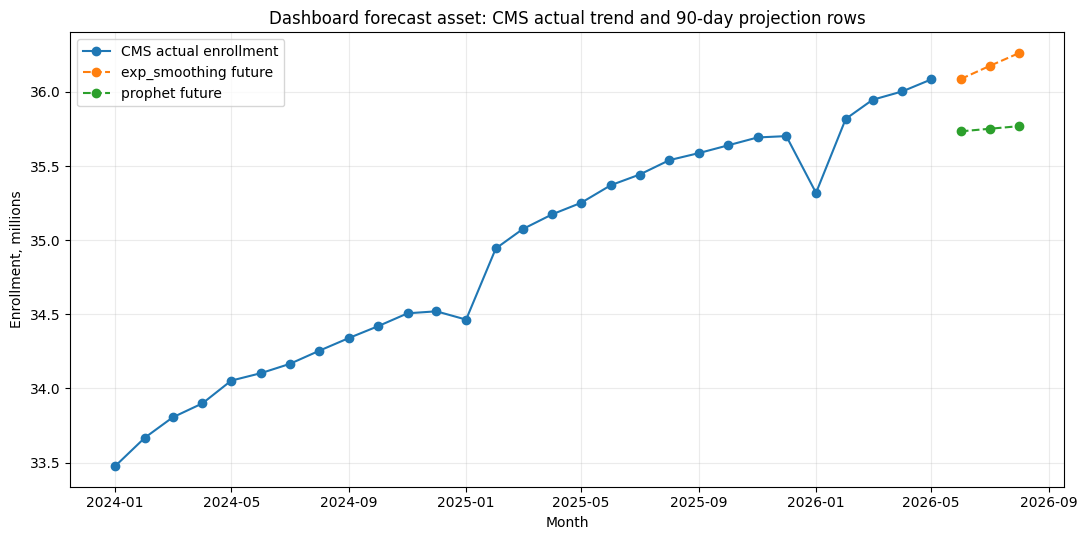

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(monthly["report_month"], monthly["observed_enrollment"] / 1_000_000, marker="o", label="CMS actual enrollment")
future = forecast[(forecast["target"].eq("observed_enrollment")) & (forecast["period_type"].eq("future"))]
for model, frame in future.groupby("model"):
    ax.plot(frame["ds"], frame["yhat"] / 1_000_000, marker="o", linestyle="--", label=f"{model} future")
ax.set_title("Dashboard forecast asset: CMS actual trend and 90-day projection rows")
ax.set_ylabel("Enrollment, millions")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(DOC_ASSET_DIR / "forecast_asset_preview.png", bbox_inches="tight")
plt.show()


## Growth Opportunity Assets

Reason: the dashboard needs a sales-friendly growth table that can support market conversations by state and plan.


In [6]:
state_opportunities = state_growth.sort_values("opportunity_rank").copy()
state_opportunities["growth_pct_display"] = (state_opportunities["growth_pct"] * 100).round(2)
state_opportunities.to_csv(TABLE_DIR / "dashboard_state_opportunities.csv", index=False)

plan_growth_export = cpsc_plan_growth.sort_values("absolute_growth", ascending=False).copy()
plan_growth_export.to_csv(TABLE_DIR / "dashboard_plan_growth_opportunities.csv", index=False)

display(state_opportunities.head(15))
print(f"State opportunity rows exported: {len(state_opportunities):,}")
print(f"Plan growth rows exported: {len(plan_growth_export):,}")


,state,first_month,last_month,first_enrollment,last_enrollment,avg_enrollment,min_enrollment,max_enrollment,avg_mom_growth_pct,volatility_mom_growth_pct,counties,absolute_growth,growth_pct,opportunity_rank,growth_pct_display
0,CA,2024-01,2026-05,3440093.0,3718525.0,3.600701e+06,3440093.0,3718525.0,0.002790,0.003548,58,278432.0,0.080937,1,8.09
1,TX,2024-01,2026-05,2510805.0,2748087.0,2.625048e+06,2510805.0,2748087.0,0.003233,0.002550,254,237282.0,0.094504,2,9.45
2,FL,2024-01,2026-05,2853027.0,3058222.0,2.958052e+06,2853027.0,3058222.0,0.002486,0.002403,67,205195.0,0.071922,3,7.19
3,NY,2024-01,2026-05,1985636.0,2169002.0,2.082661e+06,1976532.0,2169002.0,0.003264,0.014590,62,183366.0,0.092346,4,9.23
4,NC,2024-01,2026-05,1205103.0,1344776.0,1.276969e+06,1205103.0,1344776.0,0.003930,0.003469,100,139673.0,0.115901,5,11.59
5,PA,2024-01,2026-05,1541778.0,1657943.0,1.604647e+06,1541778.0,1657943.0,0.002610,0.004980,67,116165.0,0.075345,6,7.53
6,MI,2024-01,2026-05,1362242.0,1477625.0,1.424622e+06,1362242.0,1477625.0,0.002916,0.003982,83,115383.0,0.084701,7,8.47
7,OH,2024-01,2026-05,1396356.0,1487881.0,1.447907e+06,1396356.0,1487881.0,0.002277,0.003712,88,91525.0,0.065546,8,6.55
8,GA,2024-01,2026-05,1051421.0,1138849.0,1.091573e+06,1051421.0,1138849.0,0.002893,0.008662,159,87428.0,0.083152,9,8.32
9,WA,2024-01,2026-05,712478.0,787257.0,7.600052e+05,712478.0,787257.0,0.003729,0.017934,39,74779.0,0.104956,10,10.50


State opportunity rows exported: 56
Plan growth rows exported: 10,586


### Growth Preview

Elements: top states by observed enrollment lift.

Why: this is the core growth opportunity view for RCM sales targeting.


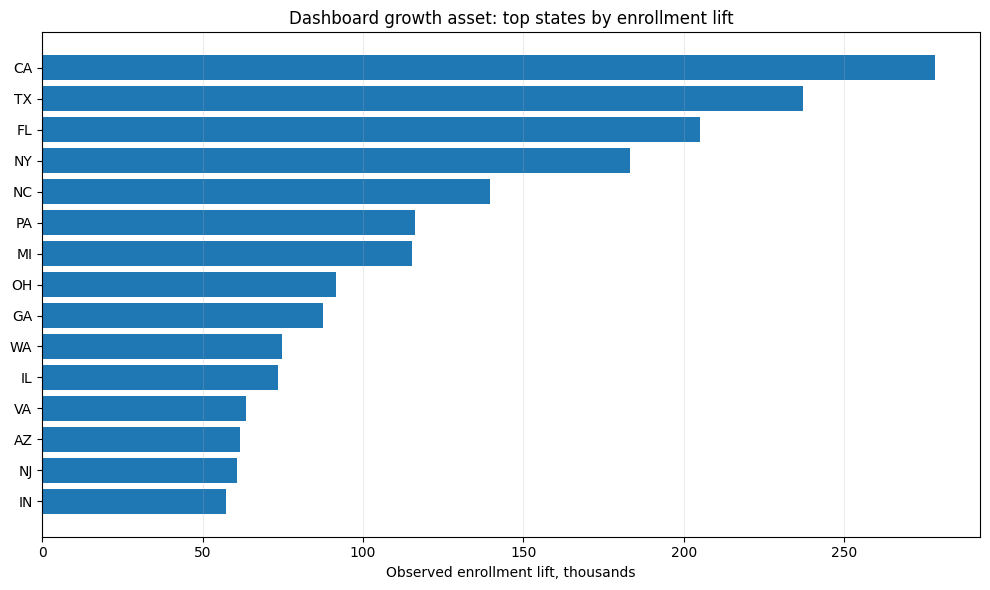

In [7]:
top_states = state_opportunities.head(15).sort_values("absolute_growth")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_states["state"], top_states["absolute_growth"] / 1000)
ax.set_title("Dashboard growth asset: top states by enrollment lift")
ax.set_xlabel("Observed enrollment lift, thousands")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(DOC_ASSET_DIR / "growth_asset_preview.png", bbox_inches="tight")
plt.show()


## Prior Authorization Assets

Reason: dashboard users need an actionable PA queue, not just a model score. This export keeps the risk score and recommendation together.


In [8]:
def pa_recommendation(row: pd.Series) -> str:
    bucket = row.get("hybrid_risk_bucket", "")
    if bucket == "high":
        return "Strengthen documentation before submission"
    if bucket == "medium":
        return "Check medical-necessity criteria"
    return "Standard submission path"

pa_export = pa.copy()
pa_export["recommendation"] = pa_export.apply(pa_recommendation, axis=1)
pa_export = pa_export.sort_values("hybrid_denial_risk", ascending=False)
pa_export.to_csv(TABLE_DIR / "dashboard_pa_queue.csv", index=False)

pa_summary = (
    pa_export.groupby(["procedure_type", "payer_type", "hybrid_risk_bucket"], as_index=False)
    .agg(
        cases=("hybrid_denial_risk", "size"),
        avg_denial_risk=("hybrid_denial_risk", "mean"),
        avg_doc_score=("doc_score", "mean"),
    )
    .sort_values(["avg_denial_risk", "cases"], ascending=[False, False])
)
pa_summary.to_csv(TABLE_DIR / "dashboard_pa_summary.csv", index=False)

display(pa_export.head(15))
display(pa_metrics)
print(f"PA queue rows exported: {len(pa_export):,}")


,procedure_type,diagnosis_category,payer_type,historical_approval_rate,doc_score,step_therapy_flag,is_expedited,prior_denial_history,missing_clinical_docs,approved,rule_denial_risk,rule_risk_bucket,ml_approval_probability,ml_denial_probability,hybrid_denial_risk,hybrid_risk_bucket,recommendation
22,part_b_drug,oncology,MA_HMO,0.750629,0.535962,1,1,1,1,0,0.527174,high,0.003063,0.996937,0.738568,high,Strengthen documentation before submission
57,DME,respiratory,MA_HMO,0.567154,0.504327,1,0,0,1,0,0.507967,high,0.001227,0.998773,0.728830,high,Strengthen documentation before submission
42,SNF,geriatrics,MA_PPO,0.508452,0.544479,0,1,1,1,0,0.496220,high,0.004974,0.995026,0.720683,high,Strengthen documentation before submission
0,SNF,geriatrics,MA_PPO,0.477514,0.382683,0,0,0,1,0,0.464605,high,0.001872,0.998128,0.704691,high,Strengthen documentation before submission
21,DME,respiratory,MA_HMO,0.617009,0.526416,0,0,1,1,0,0.461291,high,0.003266,0.996734,0.702240,high,Strengthen documentation before submission
9,post_acute,rehab,MAPD,0.409462,0.613055,0,0,1,0,1,0.459835,high,0.003168,0.996832,0.701484,high,Strengthen documentation before submission
45,home_health,chronic_care,MAPD,0.648198,0.524598,0,1,1,1,0,0.450076,high,0.003422,0.996578,0.696001,high,Strengthen documentation before submission
50,surgery,cardiology,MA_PPO,0.766520,0.146385,0,0,0,1,1,0.437488,high,0.002245,0.997755,0.689608,high,Strengthen documentation before submission
8,DME,respiratory,MA_PPO,0.553406,0.643475,1,1,0,0,0,0.414489,medium,0.962931,0.037069,0.244650,low,Standard submission path
44,home_health,chronic_care,MAPD,0.548151,0.606500,0,0,1,0,1,0.409428,medium,0.979357,0.020643,0.234474,low,Standard submission path


,model,accuracy,roc_auc,precision_approved,recall_approved,f1_approved,test_rows,note
0,gradient_boosting_pa_demo,0.933333,0.959135,0.961538,0.961538,0.961538,60,"Seeded public-data demo because CMS public PA files provide reporting schema, not request-level labels."


PA queue rows exported: 60


### PA Risk Preview

Elements: denial-risk distribution by risk bucket.

Why: this validates that the dashboard can distinguish high, medium, and low documentation-priority requests.


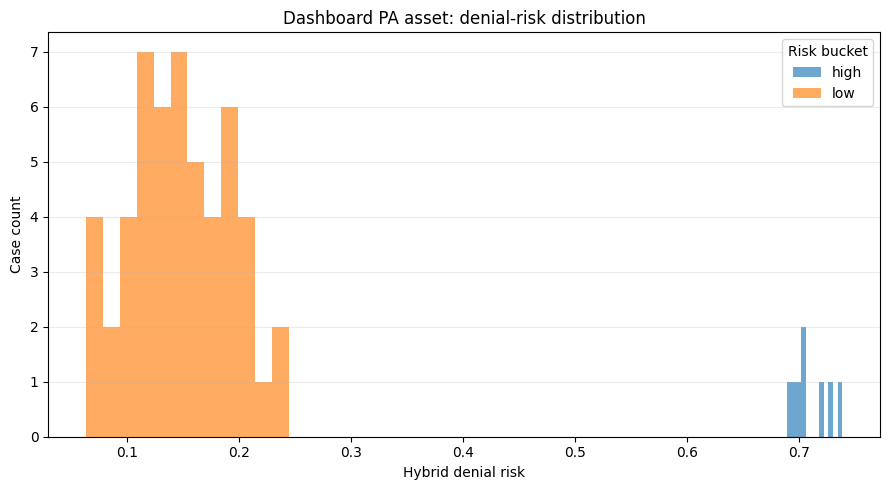

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for bucket, frame in pa_export.groupby("hybrid_risk_bucket"):
    ax.hist(frame["hybrid_denial_risk"], bins=12, alpha=0.65, label=bucket)
ax.set_title("Dashboard PA asset: denial-risk distribution")
ax.set_xlabel("Hybrid denial risk")
ax.set_ylabel("Case count")
ax.legend(title="Risk bucket")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(DOC_ASSET_DIR / "pa_asset_preview.png", bbox_inches="tight")
plt.show()


## Auth Delay Assets

Reason: delay risk is an operational queue. The export highlights procedure-payer-urgency combinations that could miss CMS timing expectations.


In [10]:
delay_export = delay.sort_values("delay_risk_score", ascending=False).copy()
delay_export.to_csv(TABLE_DIR / "dashboard_delay_queue.csv", index=False)

delay_summary = (
    delay_export.groupby(["procedure_type", "payer_type", "risk_bucket"], as_index=False)
    .agg(
        combinations=("delay_risk_score", "size"),
        avg_delay_risk=("delay_risk_score", "mean"),
        max_expected_hours=("expected_decision_hours", "max"),
    )
    .sort_values(["avg_delay_risk", "combinations"], ascending=[False, False])
)
delay_summary.to_csv(TABLE_DIR / "dashboard_delay_summary.csv", index=False)

display(delay_export.head(15))
print(f"Delay queue rows exported: {len(delay_export):,}")
print(f"High-delay combinations: {(delay_export['risk_bucket'] == 'high').sum():,}")


,procedure_type,payer_type,is_expedited,cms_decision_limit_hours,expected_decision_hours,delay_risk_score,delay_flag,risk_bucket
37,SNF,MA_HMO,1,72,152.919018,2.123875,1,high
41,SNF,MAPD,1,72,132.148072,1.835390,1,high
23,post_acute,MAPD,1,72,125.882758,1.748372,1,high
39,SNF,MA_PPO,1,72,120.989365,1.680408,1,high
21,post_acute,MA_PPO,1,72,108.768360,1.510672,1,high
43,home_health,MA_HMO,1,72,108.370524,1.505146,1,high
19,post_acute,MA_HMO,1,72,103.788321,1.441504,1,high
47,home_health,MAPD,1,72,103.148372,1.432616,1,high
15,part_b_drug,MA_PPO,1,72,95.515458,1.326604,1,high
25,surgery,MA_HMO,1,72,83.635243,1.161601,1,high


Delay queue rows exported: 48
High-delay combinations: 17


### Delay Risk Preview

Elements: delay-risk score by procedure and payer.

Why: this chart checks whether the dashboard can surface high-delay combinations before submission.


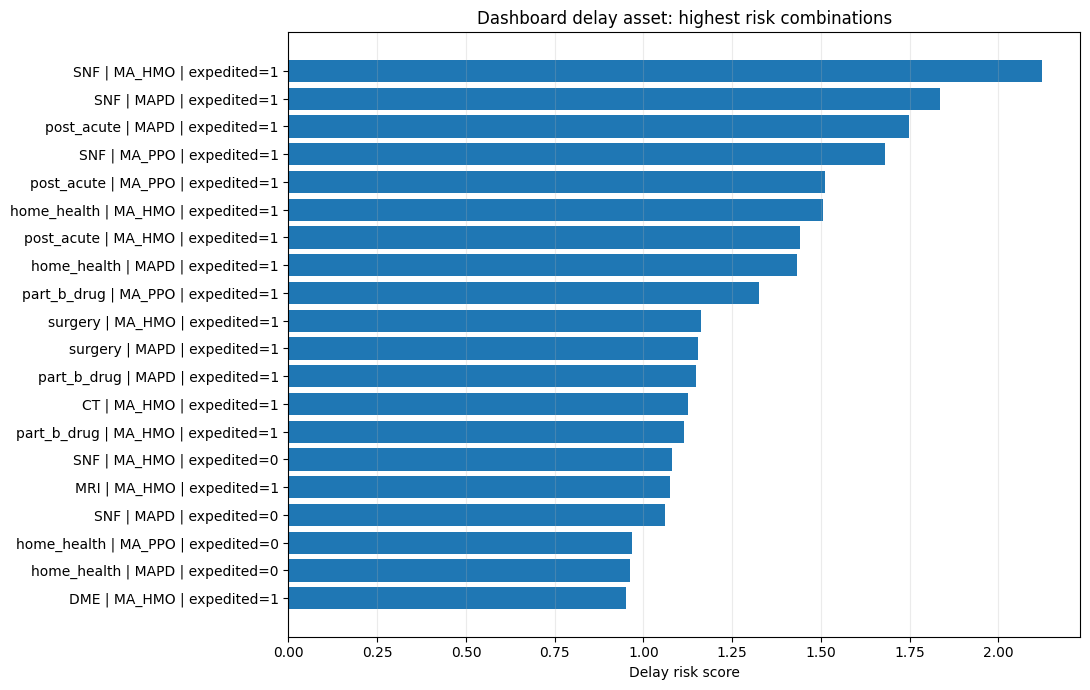

In [11]:
top_delay = delay_export.head(20).copy()
top_delay["combo"] = top_delay["procedure_type"] + " | " + top_delay["payer_type"] + " | expedited=" + top_delay["is_expedited"].astype(str)
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_delay["combo"][::-1], top_delay["delay_risk_score"][::-1])
ax.set_title("Dashboard delay asset: highest risk combinations")
ax.set_xlabel("Delay risk score")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(DOC_ASSET_DIR / "delay_asset_preview.png", bbox_inches="tight")
plt.show()


## Validation Asset

Reason: every dashboard should show what is proven, what is assumed, and what must not be overclaimed.


In [12]:
validation_export = validation.copy()
validation_export.to_csv(TABLE_DIR / "dashboard_validation_summary.csv", index=False)
display(validation_export)


,area,check,status,result,decision
0,forecasting,best_holdout_model_observed_enrollment,pass,"linear_drift MAPE=0.0005, RMSE=22175.08",Use best MAPE for headline; keep baseline comparisons visible.
1,forecasting,best_holdout_model_proxy_revenue,pass,"linear_drift MAPE=0.0005, RMSE=2550134.20",Use best MAPE for headline; keep baseline comparisons visible.
2,prior_auth,seeded_demo_classifier,pass,"accuracy=0.933, roc_auc=0.959","Frame as CMS-aligned risk prioritization, not production payer benchmarking."
3,data_quality,outlier_policy,pass,national_monthly: 4; state_monthly: 238; county_monthly: 9542,Flag outliers; do not drop source rows.
4,data_quality,forecasting_readiness,pass,"29 months, 590398 rows preserved",Rows with CMS suppressed enrollment are retained; numeric totals use observed numeric enrollment and should be described as observed/low...


## Dashboard Data Contract

Reason: Streamlit should have a stable list of expected dashboard assets. This contract helps future contributors update the dashboard safely.


In [13]:
contract_rows = [
    {
        "dashboard_tab": "Executive View",
        "asset": "dashboard_forecast_summary.csv",
        "purpose": "Actual trend and 90-day forecast rows",
        "primary_keys": "target, model, ds, period_type",
    },
    {
        "dashboard_tab": "90-Day Forecast",
        "asset": "dashboard_best_models.csv",
        "purpose": "Lowest-MAPE model by target",
        "primary_keys": "target",
    },
    {
        "dashboard_tab": "Growth Opportunity",
        "asset": "dashboard_state_opportunities.csv",
        "purpose": "State-level enrollment growth ranking",
        "primary_keys": "state",
    },
    {
        "dashboard_tab": "Plan Intelligence",
        "asset": "dashboard_plan_growth_opportunities.csv",
        "purpose": "CPSC plan-level growth ranking",
        "primary_keys": "Contract Number, Plan ID, State",
    },
    {
        "dashboard_tab": "Prior Auth Intelligence",
        "asset": "dashboard_pa_queue.csv",
        "purpose": "PA risk queue with recommendation",
        "primary_keys": "demo row index",
    },
    {
        "dashboard_tab": "Auth Delay Risk",
        "asset": "dashboard_delay_queue.csv",
        "purpose": "Procedure-payer-urgency delay queue",
        "primary_keys": "procedure_type, payer_type, is_expedited",
    },
    {
        "dashboard_tab": "Validation",
        "asset": "dashboard_validation_summary.csv",
        "purpose": "Model and data guardrails",
        "primary_keys": "validation item",
    },
]
contract = pd.DataFrame(contract_rows)
contract.to_csv(TABLE_DIR / "dashboard_data_contract.csv", index=False)
display(contract)


,dashboard_tab,asset,purpose,primary_keys
0,Executive View,dashboard_forecast_summary.csv,Actual trend and 90-day forecast rows,"target, model, ds, period_type"
1,90-Day Forecast,dashboard_best_models.csv,Lowest-MAPE model by target,target
2,Growth Opportunity,dashboard_state_opportunities.csv,State-level enrollment growth ranking,state
3,Plan Intelligence,dashboard_plan_growth_opportunities.csv,CPSC plan-level growth ranking,"Contract Number, Plan ID, State"
4,Prior Auth Intelligence,dashboard_pa_queue.csv,PA risk queue with recommendation,demo row index
5,Auth Delay Risk,dashboard_delay_queue.csv,Procedure-payer-urgency delay queue,"procedure_type, payer_type, is_expedited"
6,Validation,dashboard_validation_summary.csv,Model and data guardrails,validation item


## Export Quality Checks

Reason: this final gate confirms dashboard assets are non-empty and small enough for dashboard use.


In [14]:
export_files = [
    TABLE_DIR / "dashboard_input_inventory.csv",
    TABLE_DIR / "dashboard_table_shape_summary.csv",
    TABLE_DIR / "dashboard_best_models.csv",
    TABLE_DIR / "dashboard_forecast_summary.csv",
    TABLE_DIR / "dashboard_state_opportunities.csv",
    TABLE_DIR / "dashboard_plan_growth_opportunities.csv",
    TABLE_DIR / "dashboard_pa_queue.csv",
    TABLE_DIR / "dashboard_pa_summary.csv",
    TABLE_DIR / "dashboard_delay_queue.csv",
    TABLE_DIR / "dashboard_delay_summary.csv",
    TABLE_DIR / "dashboard_validation_summary.csv",
    TABLE_DIR / "dashboard_data_contract.csv",
]

export_check = pd.DataFrame(
    [
        {
            "file": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else np.nan,
            "rows": len(pd.read_csv(path)) if path.exists() and path.suffix == ".csv" else np.nan,
        }
        for path in export_files
    ]
)
export_check["ready"] = export_check["exists"] & export_check["rows"].fillna(0).gt(0)
export_check.to_csv(TABLE_DIR / "dashboard_export_quality_check.csv", index=False)
display(export_check)

if not export_check["ready"].all():
    raise ValueError("One or more dashboard export assets failed readiness checks.")

print("All dashboard export assets are ready.")


,file,exists,size_kb,rows,ready
0,reports\tables\dashboard_input_inventory.csv,True,0.83,12,True
1,reports\tables\dashboard_table_shape_summary.csv,True,0.22,12,True
2,reports\tables\dashboard_best_models.csv,True,0.22,2,True
3,reports\tables\dashboard_forecast_summary.csv,True,9.38,94,True
4,reports\tables\dashboard_state_opportunities.csv,True,8.31,56,True
5,reports\tables\dashboard_plan_growth_opportunities.csv,True,1884.77,10586,True
6,reports\tables\dashboard_pa_queue.csv,True,11.15,60,True
7,reports\tables\dashboard_pa_summary.csv,True,1.75,29,True
8,reports\tables\dashboard_delay_queue.csv,True,3.14,48,True
9,reports\tables\dashboard_delay_summary.csv,True,2.41,40,True


All dashboard export assets are ready.


## Final Dashboard Asset Decision

The dashboard should load compact CSV summaries plus selected Parquet tables for monthly trend views. The full long MA SCP table remains a modeling/EDA asset, not a dashboard-rendering asset.

Final decision:

- Use compact dashboard CSVs for tables, queues, and validation summaries.
- Use national/state/plan monthly Parquet files where time-series charts need efficient typed dates.
- Keep public-data guardrails visible in the dashboard.
- Do not present proxy revenue as actual collections.
- Do not present PA demo labels as production payer outcomes.
